In [1]:
# Cell 1: Environment Setup

include("scripts/initialization_helpers.jl")
include("scripts/initialization_dictionaries.jl")
using .InitializationHelpers
using .InitializationDictionaries
using OMJulia
using Plots, DataFrames, CSV

# --- Configuration ---

# 1. Directory containing the model files
MODEL_DIR = abspath("models")

# 2. Select the model to initialize
MODEL = "BESSload"

# 3. Path to the selected dynamic case file
MODEL_FILE_PATH = joinpath(MODEL_DIR, MODEL * ".mo")

# 4. Name and path of the initialized dynamic case file
INITIALIZED_MODEL = MODEL * "_initialized"
INITIALIZED_FILE_PATH = joinpath(MODEL_DIR, INITIALIZED_MODEL * ".mo")

# 5. Path to the auxiliary file
AUX_MODEL = MODEL * "_auxiliary"
AUX_FILE_PATH = joinpath(MODEL_DIR, AUX_MODEL * ".mo")

# 6. Path to the Dynawo package.mo
DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"

# 7. Path to the Modelica package.mo
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

# 8. Variable to plot after the initialized simulation
# PLOT_VARIABLE = "generatorSynchronous.terminal.i.re"  # SMIB option
PLOT_VARIABLE = "BESS.terminal.V.im"  # MyBESS option
# PLOT_VARIABLE = "PV.measurements.PPu" # MyPVCurrent option


"BESS.terminal.V.im"

In [2]:
# Cell 2: OpenModelica Setup + Model Loading

# 1. Load the dynamic model
BESS = OMJulia.OMCSession()
sendExpression(BESS, "loadModel(Complex)")
sendExpression(BESS, "loadModel(ModelicaServices)")
sendExpression(BESS, "loadFile(\"$MODELICA_PKG_PATH\")")
sendExpression(BESS, "loadFile(\"$DYNAWO_PKG_PATH\")")
sendExpression(BESS, "loadFile(\"$MODEL_FILE_PATH\")")
sendExpression(BESS, "clearMessages()")
println("Checking the dynamic model...")
chk_dyn = sendExpression(BESS, "checkModel($MODEL)", parsed=false)
println(chk_dyn)

# 2. Load the auxiliary model
StaticBESS = OMJulia.OMCSession()
sendExpression(StaticBESS, "loadModel(Complex)")
sendExpression(StaticBESS, "loadModel(ModelicaServices)")
sendExpression(StaticBESS, "loadFile(\"$MODELICA_PKG_PATH\")")
sendExpression(StaticBESS, "loadFile(\"$DYNAWO_PKG_PATH\")")
sendExpression(StaticBESS, "loadFile(\"$AUX_FILE_PATH\")")
sendExpression(StaticBESS, "clearMessages()")
println("Checking the auxiliary model...")
chk_aux = sendExpression(StaticBESS, "checkModel($AUX_MODEL)", parsed=false)
println(chk_aux)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.0yBkqRiCuK"


Checking the dynamic model...
"Check of BESSload completed successfully.
Class BESSload has 608 equation(s) and 608 variable(s).
409 of these are trivial equation(s)."



[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.6i9GfzHZph"


Checking the auxiliary model...
"Check of BESSload_auxiliary completed successfully.
Class BESSload_auxiliary has 116 equation(s) and 116 variable(s).
37 of these are trivial equation(s)."



In [3]:
# Cell 3: Simulate the auxiliary model and extract initialization values
# 1. Build and simulate the auxiliary model
ModelicaSystem(StaticBESS, AUX_FILE_PATH, AUX_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
simulate(StaticBESS, resultfile = AUX_MODEL * "_res.mat")

# 2. Get the dynamic model components that need initialization
components = get_all_components(BESS, MODEL)
initializable_components = get_initializable_components(components, INIT_PARAMS)

# 3. Extract initialization values from the auxiliary model
init_values_by_component = extract_all_initialization_values(StaticBESS, components, INIT_PARAMS)


Dict{String, Dict{String, Float64}} with 2 entries:
  "BESS"    => Dict("PF0"=>0.961607, "QInj0Pu"=>-0.142693, "Q0Pu"=>0.00856161, …
  "loadPQ1" => Dict("u0Pu.im"=>-4.75203e-7, "i0Pu.im"=>-0.0500001, "s0Pu.im"=>0…

In [4]:
# Cell 4: Build and save the initialized dynamic model
om_send(BESS, "deleteClass($INITIALIZED_MODEL)")
om_send(BESS, "clearMessages()")
om_send(BESS, "copyClass($MODEL, \"$INITIALIZED_MODEL\")")

apply_initialization_modifiers!(BESS, INITIALIZED_MODEL, initializable_components, INIT_PARAMS, init_values_by_component)

om_send(BESS, "saveModel(\"$INITIALIZED_FILE_PATH\", $INITIALIZED_MODEL)")
println("Wrote initialized model: ", INITIALIZED_FILE_PATH)


OMC -> deleteClass(BESSload_initialized)
OMC -> clearMessages()
OMC -> copyClass(BESSload, "BESSload_initialized")
OMC -> updateComponent(BESS, Dynawo.Electrical.BESS.WECC.BESSCurrentSource, BESSload_initialized, modification = $Code((u0Pu = Complex(0.9999999999996996, -7.752030663697365e-7), KiPLL = 20, DDn = 126, Kqi = 1, U0Pu = 1, tFv = 0.05, Dbd2Pu = 0.05, Q0Pu = 0.008561605273616182, EMaxPu = 0.1, UInj0Pu = 0.9999999999991438, VDLIp11 = 0.2, VRef0Pu = 1, tG = 0.017, Kvp = 1e-6, Id0Pu = 0.5000000000004282, VMaxPu = 1.1, QMaxPu = 0.75, VDLIp22 = 1.11, VUpPu = 99, Kc = 0, Kqv = 15, IMaxPu = 1.11, QFlag = false, SOCMaxPu = 0.8, RefFlag = false, VDLIq31 = 0.5, VFrz = 0, tFilterPC = 0.02, i0Pu = Complex(-0.030000006636973647, -0.008561582017521618), s0Pu = Complex(-0.03, 0.008561605273616182), QInj0Pu = -0.1426934212253142, VFlag = true, Ki = 1e-6, VDLIp32 = 1.11, VDLIq42 = 0.75, PfFlag = false, brkpt = 0.1, EMinPu = -0.1, VDLIp42 = 1.11, VDLIq41 = 1, VDLIq21 = 0.2, VDLIq12 = 0.75, IqrM

In [5]:
# Cell 5: Final simulation
InitializedBESS = OMJulia.OMCSession()
sendExpression(InitializedBESS, "loadModel(Complex)")
sendExpression(InitializedBESS, "loadModel(ModelicaServices)")
ModelicaSystem(InitializedBESS, INITIALIZED_FILE_PATH, INITIALIZED_MODEL, [MODELICA_PKG_PATH, DYNAWO_PKG_PATH])
sendExpression(InitializedBESS, "clearMessages()")
println("Checking the initialized model...")
chk_init = sendExpression(InitializedBESS, "checkModel($INITIALIZED_MODEL)", parsed=false)
println(chk_init)

initialized_resultfile_prefix = INITIALIZED_MODEL

sim_result = sendExpression(
    InitializedBESS,
    "simulate($INITIALIZED_MODEL, outputFormat=\"csv\", fileNamePrefix=\"$initialized_resultfile_prefix\")",
    parsed = false,
)

println(sim_result)

initialized_resultfile = joinpath(
    getWorkDirectory(InitializedBESS),
    initialized_resultfile_prefix * "_res.csv",
)


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.Dwfg6MyoT2"


Checking the initialized model...
"Check of BESSload_initialized completed successfully.
Class BESSload_initialized has 608 equation(s) and 608 variable(s).
409 of these are trivial equation(s)."

record SimulationResult
    resultFile = "/tmp/jl_6rjJBp/BESSload_initialized_res.csv",
    simulationOptions = "startTime = 0.0, stopTime = 3.0, numberOfIntervals = 3000, tolerance = 1e-5, method = 'dassl', fileNamePrefix = 'BESSload_initialized', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-lv=\\'LOG_STATS\\' -s=\\'ida\\' -maxIntegrationOrder=\\'2\\' -nls=\\'kinsol\\' -noHomotopyOnFirstTry -noRestart -noRootFinding -initialStepSize=\\'0.00001\\' -maxStepSize=\\'10\\''",
    messages = "LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_STATS         | info    | ### STATISTICS ###
|                 | |       | | timer
|                 | |       | | |     0.030048s          reading init.xml
|            

"/tmp/jl_6rjJBp/BESSload_initialized_res.csv"

WebIO._IJuliaInit()

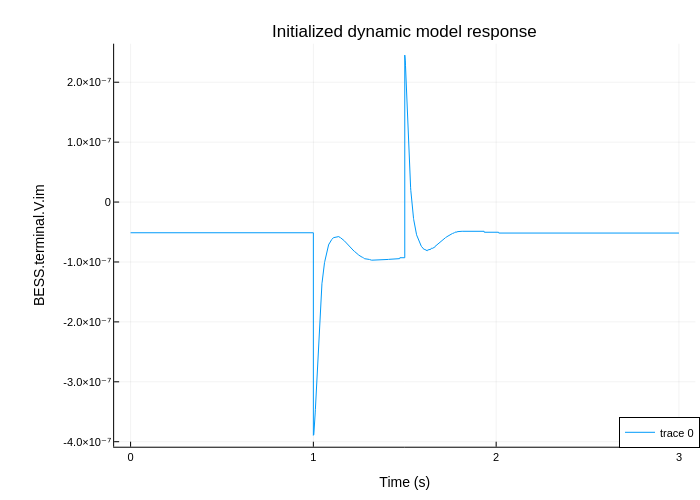

In [6]:
# Cell 6: Plot the initialized dynamic model
initialized_df = DataFrame(CSV.File(initialized_resultfile))

plotlyjs()
p = plot(initialized_df[!, "time"], initialized_df[!, PLOT_VARIABLE], label = [PLOT_VARIABLE])
plot!(p, legend = :bottomright, titlefontsize = 12, labelfontsize = 10)
title!(p, "Initialized dynamic model response")
xlabel!(p, "Time (s)")
ylabel!(p, PLOT_VARIABLE)
